# Signal Check: Do Text Pairs Predict t_start?

Answers whether the sentence embeddings of `(source_prompt, target_prompt)` pairs
contain information that is predictive of `t_start`.

The approach: freeze the encoder, extract embeddings for all pairs, then fit simple
sklearn probes on those embeddings. If a probe trained on fixed embeddings can't beat
random chance, the problem is in the features — no amount of head/MLP tuning will help.

**Probes used:**
- Logistic regression (linear probe — strictest signal test)
- Random forest (non-linear — captures interactions)
- k-NN (tests local cluster structure)

**Baselines:**
- Majority class (always predict the most common t_start)
- Random (uniform over all 11 classes)

In [17]:
import sys
from pathlib import Path

ROOT = Path.cwd().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif

from models.classification.model import SiameseEncoder
from models.classification.classify import load_data, split_data
from models.classification.settings import ENCODER_MODEL, SEED

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Encoder: {ENCODER_MODEL}")

Device: cuda
Encoder: sentence-transformers/all-MiniLM-L6-v2


### 1. Load Data

In [18]:
df = load_data()
train_df, val_df, test_df = split_data(df, seed=SEED)

print(f"Total: {len(df)}  train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")
print(f"t_start classes: {sorted(df['t_start'].unique())}")
print()
print("t_start distribution (full dataset):")
print(df['t_start'].value_counts().sort_index())

Total: 560  train: 448  val: 56  test: 56
t_start classes: [np.float64(0.0), np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]

t_start distribution (full dataset):
t_start
0.0    69
0.1    69
0.2    76
0.3    64
0.4    86
0.5    63
0.6    55
0.7    31
0.8    16
0.9    20
1.0    11
Name: count, dtype: int64


### 2. Extract Frozen Embeddings

We use the same encoder and the same `[a | b | a-b | a*b]` combination as the
model, but with completely frozen weights. This is the exact feature vector that
the MLP body sees — if the probes can't use it, the MLP can't either.

In [19]:
encoder = SiameseEncoder(ENCODER_MODEL).to(DEVICE)
for p in encoder.parameters():
    p.requires_grad_(False)
encoder.eval()

def extract_features(df: pd.DataFrame, batch_size: int = 64) -> np.ndarray:
    """Return [a | b | a-b | a*b] combined features for all rows."""
    srcs = df["source_prompt"].tolist()
    tgts = df["target_prompt"].tolist()
    all_feats = []
    with torch.no_grad():
        for i in range(0, len(srcs), batch_size):
            batch_src = srcs[i : i + batch_size]
            batch_tgt = tgts[i : i + batch_size]
            n = len(batch_src)
            emb = encoder(batch_src + batch_tgt)   # (2N, h)
            a, b = emb[:n], emb[n:]
            combined = torch.cat([a, b, a - b, a * b], dim=-1)
            all_feats.append(combined.cpu().float().numpy())
    return np.concatenate(all_feats, axis=0)

def extract_individual(df: pd.DataFrame, batch_size: int = 64) -> tuple[np.ndarray, np.ndarray]:
    """Return (source_emb, target_emb) arrays separately."""
    srcs = df["source_prompt"].tolist()
    tgts = df["target_prompt"].tolist()
    a_list, b_list = [], []
    with torch.no_grad():
        for i in range(0, len(srcs), batch_size):
            batch_src = srcs[i : i + batch_size]
            batch_tgt = tgts[i : i + batch_size]
            n = len(batch_src)
            emb = encoder(batch_src + batch_tgt)
            a_list.append(emb[:n].cpu().float().numpy())
            b_list.append(emb[n:].cpu().float().numpy())
    return np.concatenate(a_list), np.concatenate(b_list)

print("Extracting features...")
X_train = extract_features(train_df)
X_val   = extract_features(val_df)
X_test  = extract_features(test_df)

y_train = train_df["t_start_idx"].values
y_val   = val_df["t_start_idx"].values
y_test  = test_df["t_start_idx"].values

print(f"Feature shape: {X_train.shape}  (4 × hidden_dim = 4 × {X_train.shape[1]//4})")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8433.97it/s]


Extracting features...
Feature shape: (448, 1536)  (4 × hidden_dim = 4 × 384)


### 3. Baselines

In [20]:
majority = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
stratified = DummyClassifier(strategy="stratified", random_state=SEED).fit(X_train, y_train)

n_classes = len(np.unique(y_train))
acc_majority   = accuracy_score(y_test, majority.predict(X_test))
acc_stratified = accuracy_score(y_test, stratified.predict(X_test))
acc_random     = 1.0 / n_classes

print(f"Classes: {n_classes}")
print(f"Baseline — majority class:  {acc_majority:.1%}")
print(f"Baseline — random (uniform): {acc_random:.1%}")
print(f"Baseline — stratified random: {acc_stratified:.1%}")

Classes: 11
Baseline — majority class:  10.7%
Baseline — random (uniform): 9.1%
Baseline — stratified random: 8.9%


### 4. Linear Probe (Logistic Regression)

The strictest signal test. If this beats random, there is *linear* separability
in the embedding space — the model's MLP should be able to exploit it.

In [21]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Sweep regularization strengths to find best on val
Cs = [0.001, 0.01, 0.1, 1.0, 10.0]
val_accs = []
for C in Cs:
    lr = LogisticRegression(C=C, max_iter=2000, random_state=SEED, solver="lbfgs")
    lr.fit(X_train_s, y_train)
    val_accs.append(accuracy_score(y_val, lr.predict(X_val_s)))

best_C = Cs[np.argmax(val_accs)]
print(f"Val accuracies by C: {dict(zip(Cs, [f'{a:.1%}' for a in val_accs]))}")
print(f"Best C={best_C}  (val acc={max(val_accs):.1%})")

lr_best = LogisticRegression(C=best_C, max_iter=2000, random_state=SEED, solver="lbfgs")
lr_best.fit(X_train_s, y_train)

acc_lr_train = accuracy_score(y_train, lr_best.predict(X_train_s))
acc_lr_test  = accuracy_score(y_test,  lr_best.predict(X_test_s))
preds_lr = lr_best.predict(X_test_s)

print(f"\nLogistic Regression (C={best_C})")
print(f"  Train acc: {acc_lr_train:.1%}")
print(f"  Test  acc: {acc_lr_test:.1%}   (random baseline: {acc_random:.1%})")
print()
print(classification_report(y_test, preds_lr, zero_division=0))

Val accuracies by C: {0.001: '12.5%', 0.01: '14.3%', 0.1: '14.3%', 1.0: '14.3%', 10.0: '17.9%'}
Best C=10.0  (val acc=17.9%)

Logistic Regression (C=10.0)
  Train acc: 100.0%
  Test  acc: 10.7%   (random baseline: 9.1%)

              precision    recall  f1-score   support

           0       0.12      0.12      0.12         8
           1       0.11      0.12      0.12         8
           2       0.20      0.12      0.15         8
           3       0.00      0.00      0.00         9
           4       0.18      0.33      0.24         6
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         2
           8       0.50      0.20      0.29         5
          10       0.00      0.00      0.00         1

    accuracy                           0.11        56
   macro avg       0.11      0.09      0.09        56
weighted avg       0.13      0.11      0.11        56



### 5. Non-linear Probe (Random Forest)

In [22]:
rf = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

acc_rf_train = accuracy_score(y_train, rf.predict(X_train))
acc_rf_test  = accuracy_score(y_test,  rf.predict(X_test))
preds_rf = rf.predict(X_test)

print(f"Random Forest")
print(f"  Train acc: {acc_rf_train:.1%}")
print(f"  Test  acc: {acc_rf_test:.1%}   (random baseline: {acc_random:.1%})")
print()
print(classification_report(y_test, preds_rf, zero_division=0))

Random Forest
  Train acc: 100.0%
  Test  acc: 7.1%   (random baseline: 9.1%)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.11      0.12      0.12         8
           2       0.08      0.12      0.10         8
           3       0.33      0.11      0.17         9
           4       0.00      0.00      0.00         6
           5       0.33      0.20      0.25         5
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         5
          10       0.00      0.00      0.00         1

    accuracy                           0.07        56
   macro avg       0.09      0.06      0.06        56
weighted avg       0.11      0.07      0.08        56



### 6. k-NN Probe

In [23]:
# Sweep k on val
ks = [3, 5, 7, 11, 15]
knn_val_accs = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")
    knn.fit(X_train_s, y_train)
    knn_val_accs.append(accuracy_score(y_val, knn.predict(X_val_s)))

best_k = ks[np.argmax(knn_val_accs)]
print(f"Val accuracies by k: {dict(zip(ks, [f'{a:.1%}' for a in knn_val_accs]))}")

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric="cosine")
knn_best.fit(X_train_s, y_train)
acc_knn_test = accuracy_score(y_test, knn_best.predict(X_test_s))

print(f"\nk-NN (k={best_k}, cosine)")
print(f"  Test acc: {acc_knn_test:.1%}   (random baseline: {acc_random:.1%})")

Val accuracies by k: {3: '10.7%', 5: '19.6%', 7: '7.1%', 11: '8.9%', 15: '3.6%'}

k-NN (k=5, cosine)
  Test acc: 17.9%   (random baseline: 9.1%)


### 7. Probe Results Summary

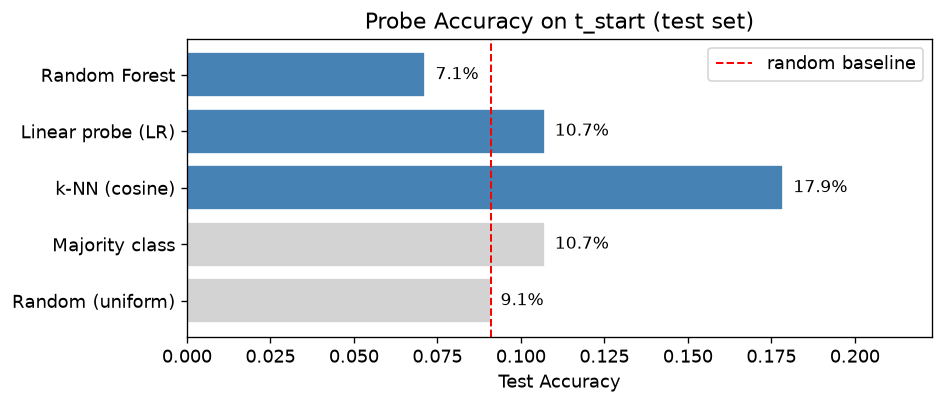


Signal present?
  WEAK — best probe achieves 17.9% vs 9.1% random (+8.8% lift).
  Some signal exists but it is limited. Consider rethinking features or target.


In [24]:
results = {
    "Random (uniform)": acc_random,
    "Majority class":   acc_majority,
    "k-NN (cosine)": acc_knn_test,
    "Linear probe (LR)": acc_lr_test,
    "Random Forest":    acc_rf_test,
}

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["lightgray", "lightgray", "steelblue", "steelblue", "steelblue"]
bars = ax.barh(list(results.keys()), list(results.values()), color=colors, edgecolor="white")
ax.axvline(acc_random, color="red", linestyle="--", linewidth=1.2, label="random baseline")
for bar, v in zip(bars, results.values()):
    ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{v:.1%}", va="center", fontsize=10)
ax.set_xlabel("Test Accuracy")
ax.set_title("Probe Accuracy on t_start (test set)")
ax.set_xlim(0, max(results.values()) * 1.25)
ax.legend()
plt.tight_layout()
plt.savefig("outputs/signal_check_probes.png", bbox_inches="tight")
plt.show()

print("\nSignal present?")
best_probe = max(acc_lr_test, acc_rf_test, acc_knn_test)
lift = best_probe - acc_random
if lift > 0.10:
    print(f"  YES — best probe achieves {best_probe:.1%} vs {acc_random:.1%} random ({lift:+.1%} lift).")
    print("  The embeddings contain useful signal; the model should be able to exploit it.")
elif lift > 0.03:
    print(f"  WEAK — best probe achieves {best_probe:.1%} vs {acc_random:.1%} random ({lift:+.1%} lift).")
    print("  Some signal exists but it is limited. Consider rethinking features or target.")
else:
    print(f"  NO — best probe achieves {best_probe:.1%} vs {acc_random:.1%} random ({lift:+.1%} lift).")
    print("  The text pairs do not predict t_start in this embedding space.")
    print("  Architectural improvements will not help — revisit the data or target definition.")

### 8. Embedding Visualizations

PCA and t-SNE of the combined features, coloured by `t_start` class.
Well-separated clusters → the signal is geometrically accessible. A uniform
mix with no clusters → no structure to exploit.

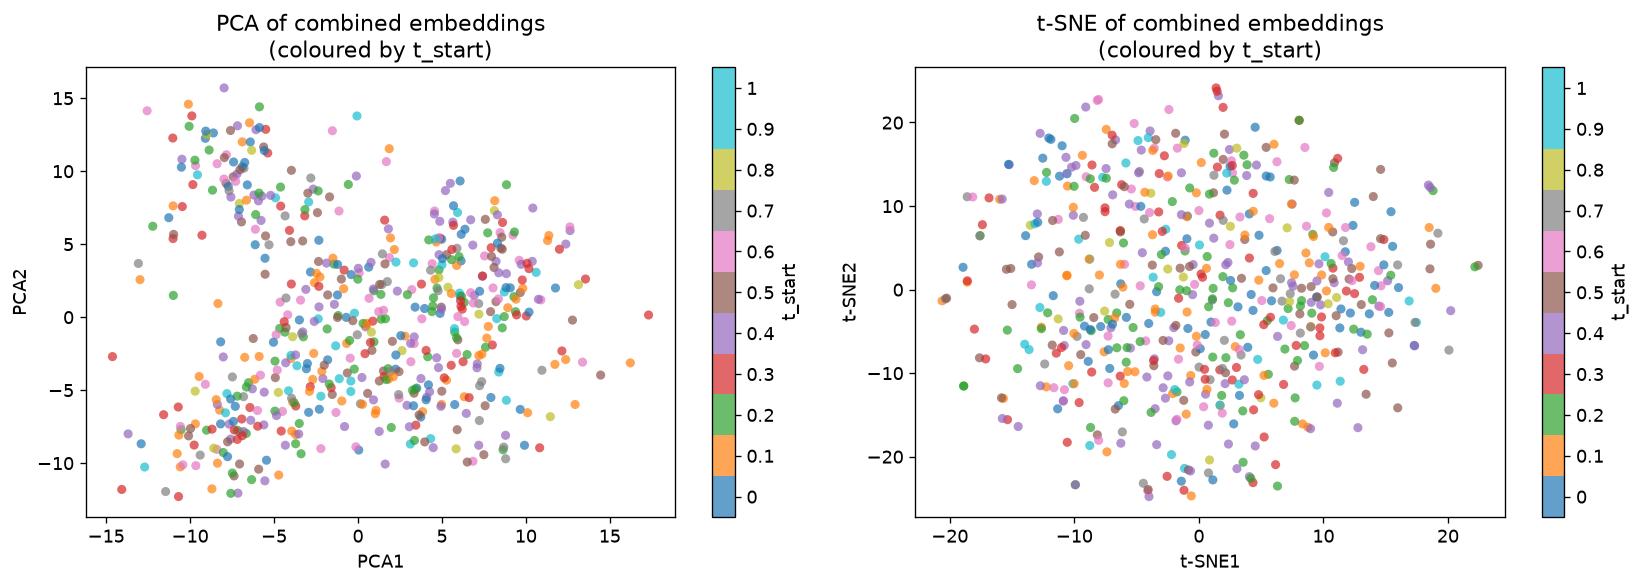

In [25]:
X_all = np.concatenate([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])
buckets = sorted(df["t_start"].unique())

X_all_s = StandardScaler().fit_transform(X_all)

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_all_s)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=min(30, len(X_all) // 4), max_iter=1000)
X_tsne = tsne.fit_transform(X_all_s)

cmap = plt.colormaps["tab10"].resampled(len(buckets))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, X_2d, title in [(axes[0], X_pca, "PCA"), (axes[1], X_tsne, "t-SNE")]:
    sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                    c=y_all, cmap=cmap, vmin=-0.5, vmax=len(buckets) - 0.5,
                    s=30, alpha=0.7, edgecolors="none")
    cbar = plt.colorbar(sc, ax=ax, ticks=range(len(buckets)))
    cbar.set_ticklabels([f"{v:.3g}" for v in buckets])
    cbar.set_label("t_start")
    ax.set_title(f"{title} of combined embeddings\n(coloured by t_start)")
    ax.set_xlabel(f"{title}1")
    ax.set_ylabel(f"{title}2")

plt.tight_layout()
plt.savefig("outputs/signal_check_embeddings.png", bbox_inches="tight")
plt.show()

### 9. Which Part of the Feature Carries Signal?

Break the combined vector into its four components and probe each one separately.
This tells us whether t_start is encoded in individual prompt identity, their
difference, or the element-wise interaction.

In [26]:
h = X_train.shape[1] // 4  # hidden_dim

def probe_component(X_tr, X_te, y_tr, y_te, name):
    sc = StandardScaler().fit(X_tr)
    lr = LogisticRegression(C=0.1, max_iter=2000, random_state=SEED, solver="lbfgs")
    lr.fit(sc.transform(X_tr), y_tr)
    acc = accuracy_score(y_te, lr.predict(sc.transform(X_te)))
    print(f"  {name:<22} {acc:.1%}")
    return acc

print("Linear probe accuracy by feature component (test set):")
component_accs = {}
for label, sl in [
    ("source (a)",          slice(0, h)),
    ("target (b)",          slice(h, 2*h)),
    ("diff (a-b)",          slice(2*h, 3*h)),
    ("hadamard (a*b)",      slice(3*h, 4*h)),
    ("full [a|b|a-b|a*b]", slice(None)),
]:
    acc = probe_component(X_train[:, sl], X_test[:, sl], y_train, y_test, label)
    component_accs[label] = acc

baseline_label = "Random baseline"
print(f"\n  {baseline_label:<22} {acc_random:.1%}")


Linear probe accuracy by feature component (test set):
  source (a)             7.1%
  target (b)             10.7%
  diff (a-b)             10.7%
  hadamard (a*b)         7.1%
  full [a|b|a-b|a*b]     10.7%

  Random baseline        9.1%


### 10. Cosine Similarity Distribution by t_start Class

Cosine similarity between source and target embeddings, grouped by `t_start`.
If prompts with large edits (high t_start) are more dissimilar, there should
be a visible trend.

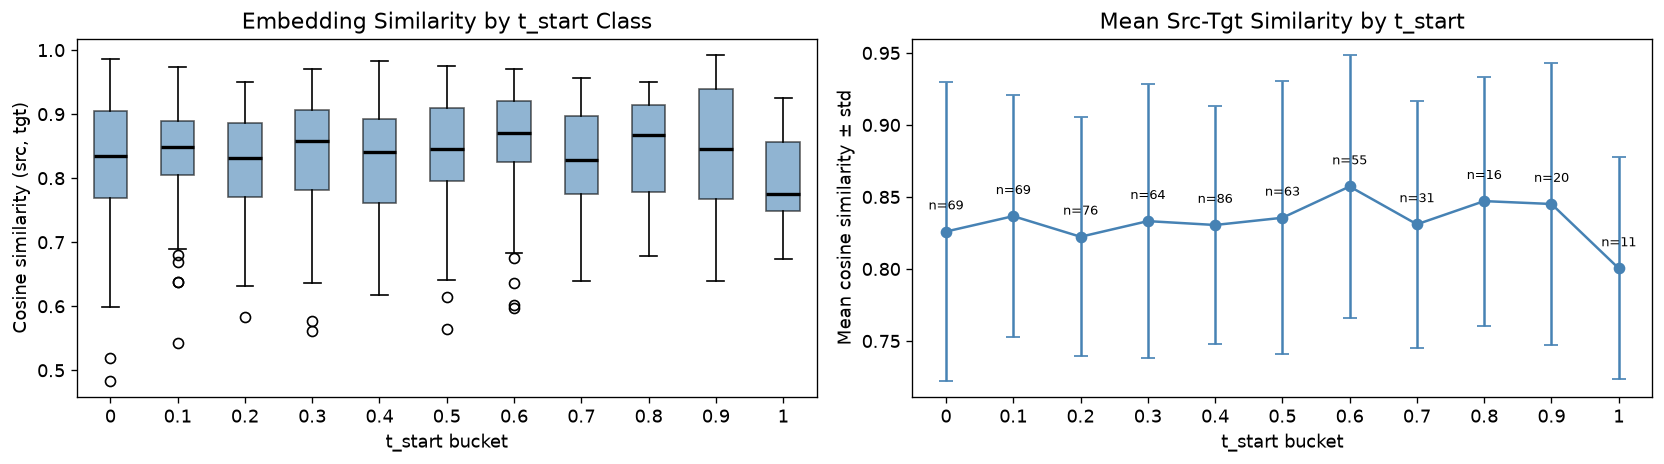

Pearson correlation (cosine_sim, t_start): 0.042
(Negative = more dissimilar prompts → higher t_start, as expected if t_start tracks edit magnitude)


In [27]:
a_all, b_all = extract_individual(df)
y_all_df = df["t_start_idx"].values

# Cosine similarity: (a · b) / (||a|| ||b||)
a_norm = a_all / (np.linalg.norm(a_all, axis=1, keepdims=True) + 1e-9)
b_norm = b_all / (np.linalg.norm(b_all, axis=1, keepdims=True) + 1e-9)
cos_sim = (a_norm * b_norm).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Box plot: cosine sim by t_start bucket
ax = axes[0]
data_by_class = [cos_sim[y_all_df == i] for i in range(len(buckets))]
bp = ax.boxplot(data_by_class, patch_artist=True,
                medianprops=dict(color="black", linewidth=2))
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)
ax.set_xticks(range(1, len(buckets) + 1))
ax.set_xticklabels([f"{v:.3g}" for v in buckets])
ax.set_xlabel("t_start bucket")
ax.set_ylabel("Cosine similarity (src, tgt)")
ax.set_title("Embedding Similarity by t_start Class")

# Mean cosine sim per class with error bars
ax = axes[1]
means = [d.mean() if len(d) > 0 else np.nan for d in data_by_class]
stds  = [d.std()  if len(d) > 1 else 0        for d in data_by_class]
ns    = [len(d) for d in data_by_class]
ax.errorbar(range(len(buckets)), means, yerr=stds, fmt="o-", color="steelblue",
            capsize=4, linewidth=1.5)
for i, (m, n) in enumerate(zip(means, ns)):
    if not np.isnan(m):
        ax.text(i, m + max(stds) * 0.1 + 0.005, f"n={n}", ha="center", fontsize=8)
ax.set_xticks(range(len(buckets)))
ax.set_xticklabels([f"{v:.3g}" for v in buckets])
ax.set_xlabel("t_start bucket")
ax.set_ylabel("Mean cosine similarity ± std")
ax.set_title("Mean Src-Tgt Similarity by t_start")

plt.tight_layout()
plt.savefig("outputs/signal_check_cosine.png", bbox_inches="tight")
plt.show()

# Correlation between cosine sim and t_start value
t_start_vals = df["t_start"].values
corr = np.corrcoef(cos_sim, t_start_vals)[0, 1]
print(f"Pearson correlation (cosine_sim, t_start): {corr:.3f}")
print("(Negative = more dissimilar prompts → higher t_start, as expected if t_start tracks edit magnitude)")

### 11. Mutual Information Between Embedding Dimensions and t_start

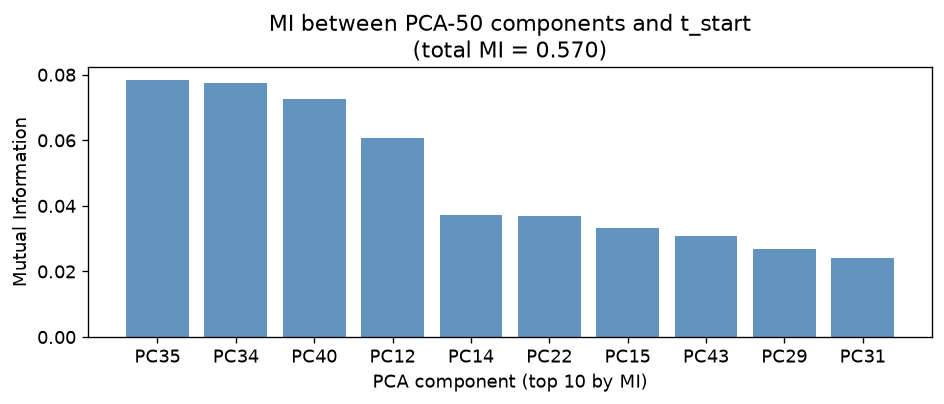

Total mutual information (50 PCs vs t_start): 0.5704
Max MI in any single PC: 0.0783
(Near-zero total MI → embeddings carry almost no information about t_start)


In [28]:
# Mutual info is expensive for high-dim features — use PCA-reduced representation
pca50 = PCA(n_components=min(50, X_train.shape[1]), random_state=SEED)
X_train_pca50 = pca50.fit_transform(StandardScaler().fit_transform(X_train))

mi = mutual_info_classif(X_train_pca50, y_train, random_state=SEED)
total_mi = mi.sum()
top_k = 10

fig, ax = plt.subplots(figsize=(8, 3.5))
top_idx = np.argsort(mi)[::-1][:top_k]
ax.bar(range(top_k), mi[top_idx], color="steelblue", alpha=0.85)
ax.set_xticks(range(top_k))
ax.set_xticklabels([f"PC{i+1}" for i in top_idx])
ax.set_xlabel("PCA component (top 10 by MI)")
ax.set_ylabel("Mutual Information")
ax.set_title(f"MI between PCA-50 components and t_start\n(total MI = {total_mi:.3f})")
plt.tight_layout()
plt.savefig("outputs/signal_check_mi.png", bbox_inches="tight")
plt.show()

print(f"Total mutual information (50 PCs vs t_start): {total_mi:.4f}")
print(f"Max MI in any single PC: {mi.max():.4f}")
print("(Near-zero total MI → embeddings carry almost no information about t_start)")

### 12. Verdict

In [29]:
best_probe_acc = max(acc_lr_test, acc_rf_test, acc_knn_test)
lift = best_probe_acc - acc_random

print("=" * 55)
print("SIGNAL CHECK SUMMARY")
print("=" * 55)
print(f"  Random baseline:       {acc_random:.1%}")
print(f"  Majority class:        {acc_majority:.1%}")
print(f"  k-NN probe:            {acc_knn_test:.1%}")
print(f"  Linear probe (LR):     {acc_lr_test:.1%}")
print(f"  Random Forest probe:   {acc_rf_test:.1%}")
print(f"  Cosine–t_start corr:   {corr:.3f}")
print(f"  Total MI (50 PCs):     {total_mi:.4f}")
print()
print(f"  Best probe lift over random: {lift:+.1%}")
print()
if lift > 0.10:
    print("VERDICT: Signal is present. The embeddings are predictive of t_start.")
    print("  -> Fix the model architecture/training; the signal is exploitable.")
elif lift > 0.03:
    print("VERDICT: Weak signal. Some information exists but it is limited.")
    print("  -> Consider: more data, alternative targets, or richer features.")
else:
    print("VERDICT: No signal. Text pairs do not predict t_start in this embedding space.")
    print("  -> Training improvements will not help. Options:")
    print("       1. Revisit what t_start represents — is it derivable from text alone?")
    print("       2. Add non-text features (e.g. token count delta, edit distance).")
    print("       3. Use a different target that is more predictable from text.")
print("=" * 55)

SIGNAL CHECK SUMMARY
  Random baseline:       9.1%
  Majority class:        10.7%
  k-NN probe:            17.9%
  Linear probe (LR):     10.7%
  Random Forest probe:   7.1%
  Cosine–t_start corr:   0.042
  Total MI (50 PCs):     0.5704

  Best probe lift over random: +8.8%

VERDICT: Weak signal. Some information exists but it is limited.
  -> Consider: more data, alternative targets, or richer features.
